# **Modelo Scissor Jack**

In [1]:
import numpy as np
import sympy
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, Point, RigidBody, KanesMethod
from sympy import symbols, solve, Matrix, latex
import matplotlib.pyplot as plt
import pandas as pd


***Parte 1 - Graficar Posición del Brazo***

Se establece esta sección del código para tener un ayuda gráfica del posicionamiento del robot ScissorJack cuando llegue a los datos (x,y) deseados. Se trabaja solo con la mitad del robot para facilitar la gráfica, valiendose de la simetría del robot. Esta función actua como un "Direct Kinematics" de la mitad del robot, permitiendo identificar los límites del robot y la configuración de sus articulaciones.

In [2]:
def dibujar_brazo_3(theta1, theta2, L1=3/100, L2=5.5/100):
    # Base
    x0, y0 = 0, 0

    # Extremo del eslabón 1
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)

    # Extremo del eslabón 2
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)

    # Extremo del eslabón 3
    # Sale desde el extremo del eslabón 2
    x3 = x2 + L2 * np.cos(theta1 - theta2)
    y3 = y2 + L2 * np.sin(theta1 - theta2)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Eslabón 1
    ax.plot(
        [x0, x1], [y0, y1],
        'o-', linewidth=4, markersize=8,
        color='steelblue', label='Eslabón 1'
    )

    # Eslabón 2
    ax.plot(
        [x1, x2], [y1, y2],
        'o-', linewidth=4, markersize=8,
        color='darkorange', label='Eslabón 2'
    )

    # Eslabón 3
    ax.plot(
        [x2, x3], [y2, y3],
        'o-', linewidth=4, markersize=8,
        color='seagreen', label='Eslabón 3'
    )

    # Base
    ax.plot(
        x0, y0,
        'ks', markersize=12, label='Base'
    )

    # Efector final
    ax.plot(
        x3, y3,
        'r*', markersize=15, label='Efector final'
    )

    # Coordenadas del efector
    ax.annotate(
        f'({x3:.3f}, {y3:.3f})',
        (x3, y3),
        textcoords="offset points",
        xytext=(10, 10)
    )

    # Límites
    limite = L1 + 2 * L2

    ax.set_xlim(-limite * 1.2, limite * 1.2)
    ax.set_ylim(-limite * 1.2, limite * 1.2)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

    ax.legend(loc='upper right')

    ax.set_title(
        f'θ1={np.rad2deg(theta1):.1f}°, '
        f'θ2={np.rad2deg(theta2):.1f}°'
    )

    plt.show()

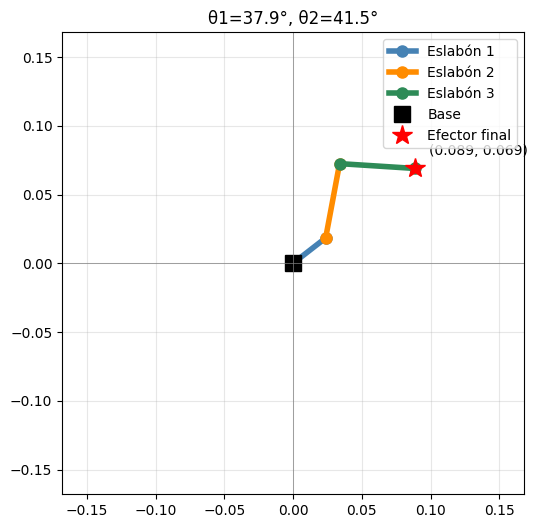

In [ ]:

dibujar_brazo_3(0.660906161001502, 0.724839863807726,3/100,5.5/100)


Se establece un espacio de trabajo aproximado desde -0.25m a 0.25m en X, y de 0 a 0.25m en Y.

***Parte 2 - Función IK***

Posteriormente, se cargan los datos de la trayectoria y se establece un modelo de Inverse Kinematics (IK) para estudiar el comportamiento de las articulaciones del robot (ángulos para llegar a las posiciones deseadas). La función numérica de Inverse Kinematics se plantea de acuerdo al siguiente diagrama:

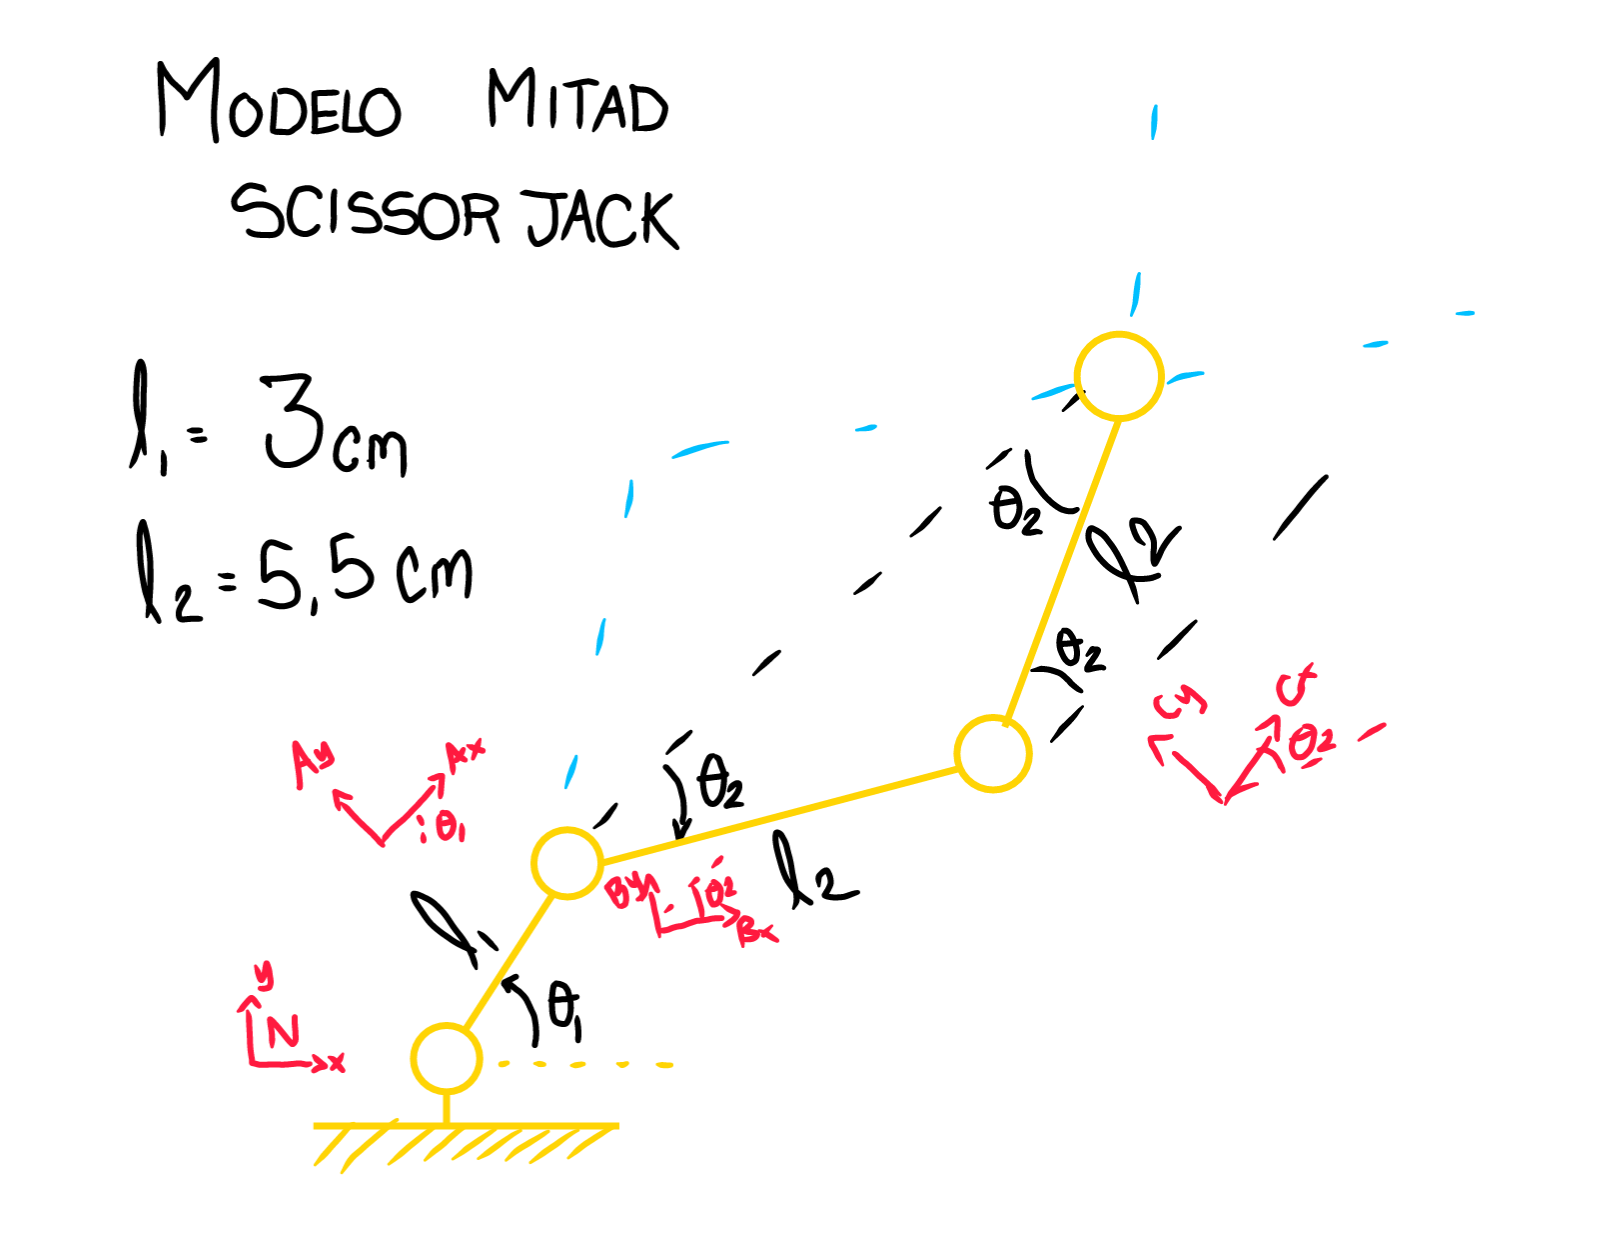

In [3]:
#Importar el archivo a Collab
from google.colab import files
uploaded = files.upload()

Saving coordenadas_estrella.csv to coordenadas_estrella.csv


In [ ]:
def hallar_angulos(coordenadas:tuple, l1, l2):
  x, y = coordenadas
  x = x/2
  y = y/2
  N = ReferenceFrame('N')
  theta1, theta2 = symbols('theta1 theta2')
  A = N.orientnew('A', 'Axis', [theta1, N.z])
  B = A.orientnew('B', 'Axis', [theta2, N.z])
  C = A.orientnew('C', 'Axis', [-theta2,N.z])

  r1 = l1*A.x
  r2 = l2*B.x
  r3 = l2*C.x
  r_tot = x*N.x + y*N.y

  loop = r1 + r2 +r3 - r_tot
  eq_x = loop.dot(N.x)
  eq_y = loop.dot(N.y)

  solucion = solve([eq_x,eq_y],[theta1, theta2])
  return solucion

Las dimensiones del modelo y simplificaciones (así como no considerar el desfase real que existe entre joints) se justifican con el fin de obtener un modelo más simplificado y que no necesita de estos valores específicos para mejorar significativamente su rendimiento, al estar trabajando en un prototipo y componentes que no cuentan con una resolución que se viese beneficiada por dichos cambios.

***Parte 3 - Coordenadas Estrella***

A continuación, se trabaja con la figura que nos fue asignada al Grupo 01: Estrella de 12 Puntas. Se aplican ciertos desfases y escalamientos a las coordenadas para garantizar que los puntos se encuentren dentro del espacio de trabajo del robot polar.

In [ ]:

df = pd.read_csv("coordenadas_estrella.csv")
df = df[['punto','x_m','y_m']]

k= 1.4
df["x"] = k * df["x_m"] -0.04 -0.05 -0.02
df["y"] = k * df["y_m"] + 0.08

l1 = 3/100
l2 = 5.5/100
lista_de_angulos = []
iter = 1
for coordx, coordy in zip(df["x"], df["y"]):
  print(coordx,coordy)
  angulos = hallar_angulos((coordx,coordy),l1,l2)[0]
  print(iter)
  print(angulos)
  lista_de_angulos.append(angulos)
  iter += 1

0.16592599999999993 0.17010399999999998
1
(0.797830936447293, 0.631068524493075)
0.16252399999999997 0.17094399999999998
2
(0.810642598507413, 0.644465347042504)
0.15912199999999996 0.17176999999999998
3
(0.823603515962781, 0.657411630822187)
0.15571999999999994 0.17260999999999999
4
(0.836795004908548, 0.669776074737338)
0.15231799999999998 0.17343599999999998
5
(0.850135635013638, 0.681730291018273)
0.14891599999999997 0.174262
6
(0.863665324050108, 0.693214615663816)
0.145514 0.175102
7
(0.877422364540628, 0.704168086856170)
0.14593399999999998 0.17693599999999998
8
(0.881124758167473, 0.692285562243407)
0.148496 0.17933
9
(0.879178263078251, 0.667137847716780)
0.15104399999999993 0.181724
10
(0.877334624436970, 0.641221515039636)
0.15359199999999998 0.18413200000000002
11
(0.875581746243668, 0.614281197125050)
0.156154 0.186526
12
(0.873797966421876, 0.586278282155407)
0.15870199999999993 0.18891999999999998
13
(0.872107951010113, 0.557112063946134)
0.16115199999999993 0.191244
14


In [ ]:
print(lista_de_angulos) # Estan en radianes

[(0.797830936447293, 0.631068524493075), (0.810642598507413, 0.644465347042504), (0.823603515962781, 0.657411630822187), (0.836795004908548, 0.669776074737338), (0.850135635013638, 0.681730291018273), (0.863665324050108, 0.693214615663816), (0.877422364540628, 0.704168086856170), (0.881124758167473, 0.692285562243407), (0.879178263078251, 0.667137847716780), (0.877334624436970, 0.641221515039636), (0.875581746243668, 0.614281197125050), (0.873797966421876, 0.586278282155407), (0.872107951010113, 0.557112063946134), (0.870584078741008, 0.527559159044477), (0.877163195501841, 0.554780641439597), (0.883916412312341, 0.580927752015334), (0.890797613083598, 0.605911054526583), (0.897856370211650, 0.629933846286737), (0.905145825487210, 0.653163465422379), (0.912579529858637, 0.675552950343064), (0.920258994277741, 0.697300514999494), (0.928094731386646, 0.718343920032075), (0.932411427184823, 0.698685833335010), (0.936165461902443, 0.674426673602344), (0.939846575499308, 0.649298969416659),

Finalmente, tras obtener la lista de ángulos correspondiente a las posiciones únicas para cada coordenada de la estrella, se comprueba la validez del modelo mediante una función que permite graficar como se vería un dibujo de acuerdo a las configuraciones angulares establecidas anteriormente y los puntos a los que llegan.

In [ ]:
def dibujar_puntos_finales(lista_angulos, L1, L2):
    fig, ax = plt.subplots(figsize=(6, 6))

    xs_finales = []
    ys_finales = []

    for theta1, theta2 in lista_angulos:
        theta1 = float(theta1)
        theta2 = float(theta2)

        x1 = L1 * np.cos(theta1)
        y1 = L1 * np.sin(theta1)

        x2 = x1 + L2 * np.cos(theta1 + theta2)
        y2 = y1 + L2 * np.sin(theta1 + theta2)

        x3 = x2 + L2 * np.cos(theta1 - theta2)
        y3 = y2 + L2 * np.sin(theta1 - theta2)

        xs_finales.append(x3)
        ys_finales.append(y3)

    ax.plot(0, 0, 'ks', markersize=2, label='Base')
    ax.plot(xs_finales, ys_finales, 'r.', markersize=2, label='Efectores finales')

    # Límites basados en los datos reales (incluyendo la base en 0,0)
    todos_x = xs_finales + [0]
    todos_y = ys_finales + [0]

    margen = 0.1 * max(L1, L2, 1e-6)  # margen mínimo para que no quede pegado al borde
    x_min, x_max = min(todos_x) - margen, max(todos_x) + margen
    y_min, y_max = min(todos_y) - margen, max(todos_y) + margen

    # Si el rango es muy chico en algún eje, forzamos un mínimo para que no se vea aplastado
    rango = max(x_max - x_min, y_max - y_min, 0.05)
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2

    ax.set_xlim(cx - rango / 2 * 1.2, cx + rango / 2 * 1.2)
    ax.set_ylim(cy - rango / 2 * 1.2, cy + rango / 2 * 1.2)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

    ax.legend(loc='upper right')
    ax.set_title(f'Puntos finales para {len(lista_angulos)} configuraciones')

    plt.show()

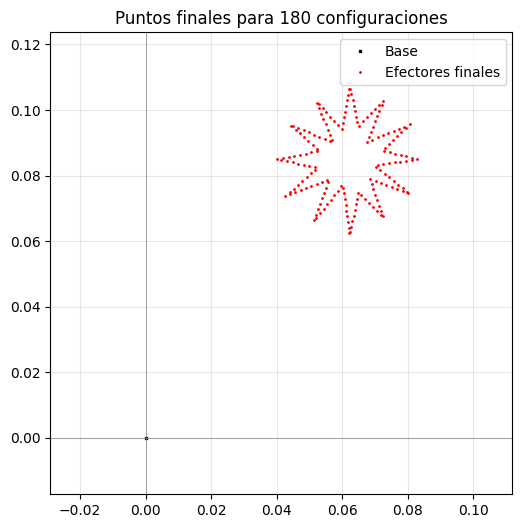

In [ ]:
dibujar_puntos_finales(lista_de_angulos, 3/100, 5.5/100)

El dibujo previo hace referencia a los puntos a los que llega la mitad del modelo del Scissor Jack. Esta figura será utilizada para comparar el error/ desfase del comportamiento real del robot con su comportamiento ideal. La escala entre ambos modelos será equivalente.

***Parte 4 - Exportar los Datos***

Finalmente, se deben exportar los datos hallado por las funciones previas a un CSV que pueda ser procesado posteriormente por un IDE que permita enviarle esta información al robot (en este caso Arduino IDE).

In [ ]:
import csv

def exportar_angulos_csv(lista_angulos, nombre_archivo='angulos_estrella_servos.csv'):
    with open(nombre_archivo, 'w', newline='') as f:
        writer = csv.writer(f, delimiter=';')
        writer.writerow(['theta1_deg', 'theta2_deg'])
        for theta1, theta2 in lista_angulos:
            t1_deg = np.degrees(float(theta1))
            t2_deg = np.degrees(float(theta2))
            t1_str = f"{t1_deg:.6f}".replace('.', ',')
            t2_str = f"{t2_deg:.6f}".replace('.', ',')
            writer.writerow([t1_str, t2_str])

exportar_angulos_csv(lista_de_angulos)

In [ ]:
files.download('angulos_estrella_servos.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Parte 5 - Toma de datos con Robot Físico***

Posteriormente se envían los datos al robot mediante el IDE de Arduino, y se toma video de los resultados de la trayectoria del ScissorJack.

***Parte 6 - Análisis de Resultados***

Se procesan los datos de la trayectoria mediante el software de Tracker, para poder traducir este comportamiento fisico en datos que se puedan evaluar. Tras obtener los datos correspondientes a este fenómeno, se procede a comparar la trayectoria ideal con la real mediante el error RMSE, que permite representa la distancia referente al error entre las trayectorias. Para ello, se hace uso del mismo código efectuado en el análisis del robot MyPalletizer 260.

In [12]:
#Importar el archivo a Collab
from google.colab import files
uploaded = files.upload()

Saving datostracker.csv to datostracker.csv


In [67]:
#Comparación experimental

#PROBLEMA: Queremos comparar puntos relativos entre curva ideal y curva real.
#csv tiene 180 puntos, tracker saca aprox 5000-8000. Vamos a parametrizar ambas curvas y compararlas a un x% (s/1) de completar la trayectoria.

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd


def alinear_trayectoria(x_ideal, y_ideal, x_real, y_real, P_ref,
                          activar_escala=True,
                          activar_rotacion=True,
                          activar_traslacion=True):
    """
    Escala, rota y traslada la trayectoria real (Tracker, en píxeles)
    para que coincida con el sistema de referencia de la trayectoria
    ideal (csv original), usando 2 puntos correspondientes conocidos.

    P_ref: [idx_ideal_1, idx_ideal_2, idx_real_1, idx_real_2]

    """

    pts_ideal_ref = np.array([
        [x_ideal[P_ref[0]], y_ideal[P_ref[0]]],     # punto de referencia 1 (ideal, mm)
        [x_ideal[P_ref[1]], y_ideal[P_ref[1]]],     # punto de referencia 2 (ideal, mm)
    ])

    pts_tracker_ref = np.array([
        [x_real[P_ref[2]], y_real[P_ref[2]]],       # mismo punto físico 1 (Tracker, px)
        [x_real[P_ref[3]], y_real[P_ref[3]]],       # mismo punto físico 2 (Tracker, px)
    ])

    pts_origen = np.asarray(pts_tracker_ref, dtype=float)   # Tracker (px)
    pts_destino = np.asarray(pts_ideal_ref, dtype=float)    # Ideal (mm)

    # --- Centrar ambos conjuntos ---
    centroide_o = pts_origen.mean(axis=0)
    centroide_d = pts_destino.mean(axis=0)
    o_centrado = pts_origen - centroide_o
    d_centrado = pts_destino - centroide_d

    # --- Rotación óptima (SVD / algoritmo de Umeyama-Kabsch) ---
    if activar_rotacion:
        H = o_centrado.T @ d_centrado
        U, S, Vt = np.linalg.svd(H)
        D = np.eye(2)
        if np.linalg.det(Vt.T @ U.T) < 0:
            D[-1, -1] = -1
        R = Vt.T @ D @ U.T
    else:
        R = np.eye(2)
        S = None

    # --- Escala óptima ---
    if activar_escala:
        var_o = np.sum(o_centrado**2)
        if activar_rotacion:
            s = np.sum(S * np.diag(D)) / var_o
        else:
            # Sin rotación: escala óptima en mínimos cuadrados sin rotar
            s = np.sum(o_centrado * d_centrado) / var_o
    else:
        s = 1.0

    # --- Traslación ---
    if activar_traslacion:
        t = centroide_d - s * R @ centroide_o
    else:
        t = np.zeros(2)

    # --- Aplicar transformación a TODA la trayectoria real ---
    puntos_real = np.column_stack([x_real, y_real]).astype(float)
    puntos_real_transformados = (s * (R @ puntos_real.T).T) + t

    x_real_transformado = puntos_real_transformados[:, 0]
    y_real_transformado = puntos_real_transformados[:, 1]

    return x_real_transformado, y_real_transformado


def parametrizar_por_arco(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # --- Eliminar puntos consecutivos duplicados (ds=0) ---
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)

    mask = np.concatenate([[True], ds > 1e-9])  # conserva el primer punto siempre
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        raise ValueError("Muy pocos puntos únicos tras eliminar duplicados.")

    # --- Recalcular longitud de arco con los puntos ya filtrados ---
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate([[0], np.cumsum(ds)])
    s_norm = s / s[-1]

    fx = interp1d(s_norm, x, kind='cubic')
    fy = interp1d(s_norm, y, kind='cubic')
    return fx, fy


def rmse_trayectorias(x_ideal, y_ideal, x_real, y_real, n_puntos=1000):
    fx_ideal, fy_ideal = parametrizar_por_arco(x_ideal, y_ideal)
    fx_real, fy_real = parametrizar_por_arco(x_real, y_real)

    s_common = np.linspace(0, 1, n_puntos)

    x_i, y_i = fx_ideal(s_common), fy_ideal(s_common)
    x_r, y_r = fx_real(s_common), fy_real(s_common)

    errores = np.sqrt((x_i - x_r)**2 + (y_i - y_r)**2)
    rmse = np.sqrt(np.mean(errores**2))

    # --- R^2 ---
    ss_res = np.sum((x_i - x_r)**2 + (y_i - y_r)**2)
    ss_tot = np.sum((x_i - np.mean(x_i))**2 + (y_i - np.mean(y_i))**2)
    r2 = 1 - ss_res/ss_tot

    return rmse, r2, errores, s_common


Index(['trayectoria_id', 'figura', 'punto', 'x_m', 'y_m'], dtype='object')
   trayectoria_id              figura  punto      x_m      y_m
0               1  Estrella irregular      0  0.19709  0.06436
1               1  Estrella irregular      1  0.19466  0.06496
2               1  Estrella irregular      2  0.19223  0.06555
3               1  Estrella irregular      3  0.18980  0.06615
4               1  Estrella irregular      4  0.18737  0.06674
Index(['x', 'y'], dtype='object')
        x       y
0  0.0301  0.0124
1  0.0299  0.0125
2  0.0299  0.0122
3  0.0300  0.0119
4  0.0287  0.0121


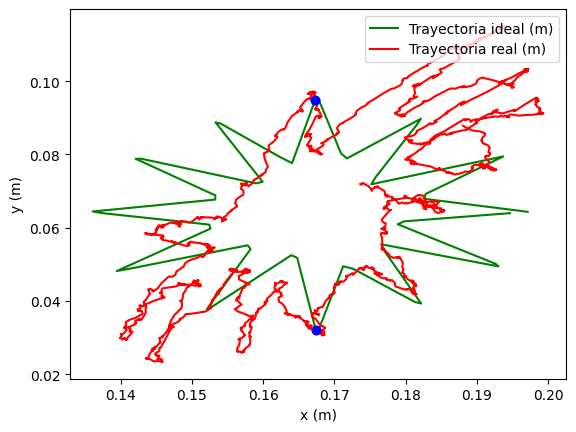

RMSE: 41.6986 mm
R^2: -2.5227


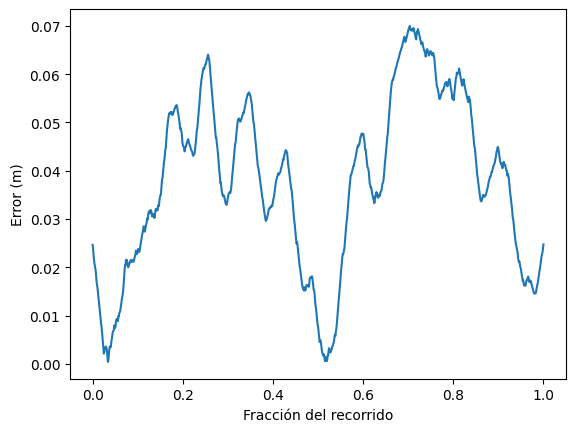

In [73]:
#Leo trayectorias
df_ideal = pd.read_csv("coordenadas_estrella.csv")
x_ideal = df_ideal["x_m"].to_numpy()
y_ideal = df_ideal["y_m"].to_numpy()

print(df_ideal.columns)
print(df_ideal.head())

df_tracker = pd.read_csv("datostracker.csv", sep=",", decimal=".")

print(df_tracker.columns)
print(df_tracker.head())

x_tracker = df_tracker["x"].to_numpy() # ajusta nombres según cómo exportó Tracker
y_tracker = df_tracker["y"].to_numpy()

#Escalo, traslado, roto puntos de tracker para ajustarse a reales. Debo ingresar 4 puntos coincidentes(en funcion)
#indices de puntos de referencia:
         #Ideal      #Real

psk06=[43, 135, 1183, 3286]
psk05=[43, 135, 1500, 100]
p05def=[43, 135, 107, 319]
prueba = [43, 135, 1750, 550]
P_ref = prueba
x_real_mm, y_real_mm = alinear_trayectoria(x_ideal, y_ideal, x_tracker, y_tracker, P_ref)

#Parametrizo y comparo:

rmse, r2, errores, s = rmse_trayectorias(x_ideal, y_ideal, x_real_mm, y_real_mm)

# Visualizar dónde se desvía más el movimiento real
import matplotlib.pyplot as plt

#Graficar trayectorias sobrepuestas

plt.plot(x_ideal, y_ideal, label="Trayectoria ideal (m)", color="green")
plt.plot(x_real_mm, y_real_mm, label="Trayectoria real (m)", color="red")
plt.plot(x_ideal[P_ref[0]], y_ideal[P_ref[0]], 'bo') #Superior ideal
plt.plot(x_ideal[P_ref[1]], y_ideal[P_ref[1]], 'bo') #Inferior ideal
plt.plot(x_real_mm[P_ref[2]], y_real_mm[P_ref[2]], 'bo') #Superior real
plt.plot(x_real_mm[P_ref[3]], y_real_mm[P_ref[3]], 'bo') #Inferior real
plt.legend(loc="upper right")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

plt.plot(s, errores)
plt.xlabel("Fracción del recorrido")
plt.ylabel("Error (m)")
rmse_mm = round(float(rmse*1000), 4)
r2 = round(float(r2), 4)
print(f"RMSE: {rmse_mm} mm")
print(f"R^2: {r2}")
plt.show()

Finalmente se obtiene un error RMSE de 41.7 mm aproximadamente. Sin embargo, la trayectoria del robot muestra una trayectoria aproximada a una estrella, por lo que se evidencia que el robot cumple con su objetivo. Posteriormente se evaluará el grado de satisfacción de dicho resultado.